# Préparation des fichiers :

*  Limitation 2021-2025
*  Vérif des données pour future liaison des fichiers
*  Gestion de NaN et vérif



### Import si usage Drive

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Liora'

# Vérification si le dossier existe et affichage du contenu
if os.path.exists(base_path):
    print("Accès réussi au dossier Liora !")
    print("Contenu du dossier :", os.listdir(base_path))

    # Se déplacer dans ce dossier pour faciliter les imports suivants
    os.chdir(base_path)
else:
    print("Le dossier n'a pas été trouvé. Vérifie bien l'orthographe (majuscules/minuscules) ou si le dossier est dans un sous-dossier.")

Mounted at /content/drive
Accès réussi au dossier Liora !
Contenu du dossier : ['LFB Mobilisation data from January 2009 - 2014.xlsx', 'Mobilisations Metadata.xlsx', 'Incident Metadata.xlsx', 'LFB Incident data from 2024 onwards.xlsx', 'LFB Incident data from 2018 - 2023.xlsx', 'LFB Mobilisation data from 2015 - 2020.xlsx', 'LFB Mobilisation data from 2025.csv', 'LFB Mobilisation data from 2021 - 2024.csv', 'LFB Incident data from 2018 - 2023.csv', 'LFB Incident data from 2024 onwards.csv', 'LFB Mobilisation data from January 2009 - 2014.csv', 'LFB Mobilisation data from 2015 - 2020.csv', 'Metadata Incident_complet.docx', 'Metadata_Mobilisation_complet.docx', 'LFB Incident data from 2009 - 2017.csv', 'all_mobilisations.csv', 'mobilisation_completv26pm.csv', 'Incident_complet.csv', 'incident_complet.csv', 'mobilisation_complet.csv', 'incident_complet_2021_2025.parquet', 'mobilisation_complet_2021_2025.parquet', 'incident_complet.parquet', 'mobilisation_complet.parquet', 'incident_comple

### Import si usage local

In [2]:
base_path = ""

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.4 MB/s eta 0:00:00


### Lecture des fichiers

In [4]:
incident_complet = pd.read_parquet('incident_complet.parquet', engine='fastparquet')
mobilisation_complet = pd.read_parquet('mobilisation_complet.parquet', engine='fastparquet')

### Limitations des données 2021-2025 : incidents

In [5]:
# On s'assure que Pandas interprète correctement les dates
incident_complet['DateOfCall'] = pd.to_datetime(incident_complet['DateOfCall'])

# Définition des bornes (1er Janvier 2021 au 31 décembre 2025 inclus)
date_debut = '2021-01-01 00:00:00'
date_fin = '2025-12-31 23:59:59'

# Application du filtre
mask_periode = (incident_complet['DateOfCall'] >= date_debut) & (incident_complet['DateOfCall'] <= date_fin)
incident_complet_2021_2025 = incident_complet.loc[mask_periode].copy()

# Sauvegarde du fichier final
output_file = 'incident_complet_2021_2025.parquet'
incident_complet_2021_2025.to_parquet(output_file, index=False)

print(f"\n Fichier enregistré avec succès : {output_file}")


 Fichier enregistré avec succès : incident_complet_2021_2025.parquet


### Limitations des données 2021-2025 : mobilisations

In [6]:

# On s'assure que Pandas interprète correctement les dates
mobilisation_complet['DateAndTimeMobilised'] = pd.to_datetime(mobilisation_complet['DateAndTimeMobilised'])

# Définition des bornes (1er Janvier 2021 au 31 décembre 2025 inclus)
date_debut = '2021-01-01 00:00:01'
date_fin = '2025-12-31 23:59:59'

# Application du filtre
mask_periode = (mobilisation_complet['DateAndTimeMobilised'] >= date_debut) & (mobilisation_complet['DateAndTimeMobilised'] <= date_fin)
mobilisation_complet_2021_2025 = mobilisation_complet.loc[mask_periode].copy()
mobilisation_complet_2021_2025 = mobilisation_complet_2021_2025.drop_duplicates()

# Sauvegarde du fichier final
output_file = 'mobilisation_complet_2021_2025.parquet'
mobilisation_complet_2021_2025.to_parquet(output_file, index=False)

print(f"\n Fichier enregistré avec succès : {output_file}")
mobilisation_complet_2021_2025.info()


 Fichier enregistré avec succès : mobilisation_complet_2021_2025.parquet
<class 'pandas.core.frame.DataFrame'>
Index: 930521 entries, 1785429 to 2721137
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         926390 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        926371 non-null  Int64         
 10  TravelTimeSeconds         926358 non-null  Int64    

In [7]:
mobilisation_complet_2021_2025 = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')
mobilisation_complet_2021_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930521 entries, 0 to 930520
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         926390 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        926371 non-null  Int64         
 10  TravelTimeSeconds         926358 non-null  Int64         
 11  AttendanceTimeSeconds     930521 non-null  Int64         
 12  Da

### Check des premières et dernières entrées de chaque source

In [8]:
print('Incident')
display(incident_complet_2021_2025.shape,incident_complet_2021_2025.head(),incident_complet_2021_2025.tail())
print('\n')
print('_______________________________')
print('\n')
print('Mobilisation')
display(mobilisation_complet_2021_2025.shape,mobilisation_complet_2021_2025.head(),mobilisation_complet_2021_2025.tail())

Incident


(633178, 39)

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
1297831,000004-01012021,2021-01-01,2021,00:06:47,0,False Alarm,AFA,,Non Residential,Single shop,...,181.0,Hornsey,NaN,,1.0,1.0,1,60,346,1.0
1297832,000005-01012021,2021-01-01,2021,00:07:46,0,Fire,Secondary Fire,,Outdoor,Tree scrub,...,250.0,Woodford,NaN,,1.0,1.0,1,60,346,1.0
1297833,000006-01012021,2021-01-01,2021,00:08:21,0,False Alarm,False alarm - Good intent,,Outdoor,Road surface/pavement,...,376.0,Dagenham,NaN,,1.0,1.0,1,60,346,1.0
1297834,000007-01012021,2021-01-01,2021,00:12:16,0,False Alarm,False alarm - Good intent,,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,409.0,Wandsworth,445.0,Fulham,5.0,5.0,5,99,571,4.0
1297835,000009-01012021,2021-01-01,2021,00:14:51,0,Fire,Primary Fire,,Road Vehicle,Car,...,362.0,Stratford,NaN,,1.0,1.0,1,60,346,2.0


,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
1931004,244502-31122025,2025-12-31,2025,23:47:31,23,Special Service,Special Service,Flooding,Dwelling,House - single occupancy,...,340.0,Harrow,NaN,,1.0,1.0,1,60,467,1.0
1931005,244503-31122025,2025-12-31,2025,23:47:41,23,Special Service,Special Service,RTC,Road Vehicle,Car,...,251.0,Islington,NaN,,1.0,1.0,1,60,467,1.0
1931006,244507-31122025,2025-12-31,2025,23:50:49,23,False Alarm,AFA,,Non Residential,Restaurant/cafe,...,428.0,Old Kent Road,691.0,Dowgate,4.0,4.0,4,60,467,1.0
1931007,244511-31122025,2025-12-31,2025,23:55:43,23,Special Service,Special Service,Flooding,Dwelling,Purpose Built Flats/Maisonettes - Up to 3 stor...,...,270.0,Leyton,NaN,,1.0,1.0,1,60,467,1.0
1931008,244512-31122025,2025-12-31,2025,23:58:31,23,Fire,Secondary Fire,,Outdoor,Cycle path/public footpath/bridleway,...,270.0,Southall,NaN,,1.0,1.0,1,60,467,2.0




_______________________________


Mobilisation


(930521, 24)

,IncidentNumber,CalYear,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,...,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,BoroughName,WardName
0,000004-01012021,2021,0,5769249,A321,1,2021-01-01 00:06:00,2021-01-01 00:07:00,2021-01-01 00:09:00,48,...,A32,Hornsey,Home Station,1,Initial,Initial Mobilisation,<NA>,None,HARINGEY,Muswell Hill
1,000005-01012021,2021,0,5769250,F351,1,2021-01-01 00:07:00,2021-01-01 00:09:00,2021-01-01 00:11:00,114,...,F35,Woodford,Home Station,1,Initial,Initial Mobilisation,<NA>,None,REDBRIDGE,MONKHAMS
2,000006-01012021,2021,0,5769251,F412,1,2021-01-01 00:08:00,2021-01-01 00:10:00,2021-01-01 00:14:00,131,...,F41,Dagenham,Home Station,1,Initial,Initial Mobilisation,12,Not held up,BARKING AND DAGENHAM,Village
3,000007-01012021,2021,0,5769252,H331,1,2021-01-01 00:12:00,2021-01-01 00:13:00,2021-01-01 00:19:00,53,...,H33,Wandsworth,Home Station,1,Initial,Initial Mobilisation,8,Traffic calming measures,WANDSWORTH,West Hill
4,000007-01012021,2021,0,5769253,G351,2,2021-01-01 00:12:00,2021-01-01 00:13:00,2021-01-01 00:19:00,69,...,G35,Fulham,Home Station,2,Initial,Initial Mobilisation,<NA>,None,WANDSWORTH,West Hill


,IncidentNumber,CalYear,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,...,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,BoroughName,WardName
930516,244502-31122025,2025,23,7196955,G211,1,2025-12-31 23:49:00,2025-12-31 23:51:00,2025-12-31 23:55:00,77,...,G21,Harrow,Home Station,1,Initial,Initial Mobilisation,<NA>,None,HARROW,GREENHILL
930517,244507-31122025,2025,23,7196956,A281,2,2025-12-31 23:52:00,2025-12-31 23:55:00,2026-01-01 00:04:00,155,...,A28,Dowgate,Home Station,2,Initial,Initial Mobilisation,9,"Traffic, roadworks, etc",SOUTHWARK,BOROUGH & BANKSIDE
930518,244507-31122025,2025,23,7196958,E351,1,2025-12-31 23:55:00,2025-12-31 23:56:00,2026-01-01 00:02:00,100,...,E35,Old Kent Road,Home Station,1,Initial,Initial Mobilisation,9,"Traffic, roadworks, etc",SOUTHWARK,BOROUGH & BANKSIDE
930519,244511-31122025,2025,23,7196961,F291,1,2025-12-31 23:56:00,2025-12-31 23:58:00,2026-01-01 00:00:00,106,...,F29,Leyton,Home Station,1,Initial,Initial Mobilisation,<NA>,None,WALTHAM FOREST,GROVE GREEN
930520,244507-31122025,2025,23,7196962,E341,Not Used,2025-12-31 23:57:00,2025-12-31 23:58:00,2026-01-01 00:04:00,69,...,E34,Dockhead,Home Station,3,Initial,Initial Mobilisation,<NA>,None,SOUTHWARK,BOROUGH & BANKSIDE


In [9]:
incident_complet_2021_2025.describe()

,DateOfCall,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
count,633178,633178.000000,633178.000000,633178.0,633178.0,258035.000000,258035.000000,633178.000000,633178.000000,258035.000000,258035.000000,597913.000000,227928.000000,624687.000000,624687.000000,633178.000000,633178.000000,633178.000000,633166.000000
mean,2023-08-14 06:36:30.981998848,2023.103480,13.345652,17434562031.160007,20472124.836153,530688.072626,180384.241397,530627.941432,180410.757638,51.300433,-0.117458,320.083556,403.189599,1.412286,1.545344,1.588732,75.836400,502.051333,1.304877
min,2021-01-01 00:00:00,2021.000000,0.000000,0.0,4200558.0,503587.000000,155901.000000,503550.000000,155950.000000,0.000000,-0.510069,1.000000,1.000000,1.000000,1.000000,1.000000,60.000000,346.000000,1.000000
25%,2022-06-04 00:00:00,2022.000000,9.000000,0.0,20401226.0,524990.500000,175955.000000,525150.000000,175950.000000,51.468194,-0.199524,235.000000,307.000000,1.000000,1.000000,1.000000,60.000000,364.000000,1.000000
50%,2023-09-03 00:00:00,2023.000000,14.000000,0.0,21201567.0,530847.000000,180989.000000,530950.000000,181050.000000,51.512849,-0.115847,301.000000,381.000000,1.000000,1.000000,1.000000,60.000000,388.000000,1.000000
75%,2024-11-05 00:00:00,2024.000000,19.000000,10008155430.0,22100813.0,537082.000000,185060.000000,536350.000000,185250.000000,51.548973,-0.024358,383.000000,473.000000,2.000000,2.000000,2.000000,60.000000,463.000000,1.000000
max,2025-12-31 00:00:00,2025.000000,23.000000,200004439603.0,99990422.0,561126.000000,200885.000000,611150.000000,302450.000000,51.691458,0.322219,1200.000000,1200.000000,14.000000,14.000000,194.000000,69016.000000,494615.000000,210.000000
std,NaN,1.401074,6.358915,42661429789.824257,4410251.604299,10491.498919,7479.398825,9758.434357,7441.114447,3.257826,0.150948,135.548416,148.735198,0.799196,0.923044,1.407109,282.392387,1928.791590,1.480541


### Remplissage des valeurs manquantes TurnoutTimeSecondes et TravelTimeSeconds si possibe et nettoyage des valeurs
Cette modif était nécéssaire sur les données antérieures à 2021, n'est plus utile pour 2021-2025.

In [13]:

# Préparation colonnes au format "Nullable Float" pour accepter les calculs
mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].astype('float64')
mobilisation_complet['TurnoutTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'].astype('float64')

# État AVANT
avant_turnout = mobilisation_complet['TurnoutTimeSeconds'].isna().sum()
avant_travel = mobilisation_complet['TravelTimeSeconds'].isna().sum()

# Conversion dates
cols_dates = ['DateAndTimeMobile', 'DateAndTimeMobilised', 'DateAndTimeArrived']
for col in cols_dates:
    mobilisation_complet[col] = pd.to_datetime(mobilisation_complet[col], errors='coerce')

# Calculs
calc_turnout = (mobilisation_complet['DateAndTimeMobile'] - mobilisation_complet['DateAndTimeMobilised']).dt.total_seconds()
calc_travel = (mobilisation_complet['DateAndTimeArrived'] - mobilisation_complet['DateAndTimeMobile']).dt.total_seconds()

mobilisation_complet['TurnoutTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'].fillna(calc_turnout)
mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].fillna(calc_travel)

# Traitement des négatifs et moyennes - On traite les négatifs comme des manquants (NA)
mobilisation_complet.loc[mobilisation_complet['TravelTimeSeconds'] < 0, 'TravelTimeSeconds'] = np.nan

# Calcul de la moyenne par station (ignore automatiquement les NA)
station_means = mobilisation_complet.groupby('DeployedFromStation_Name')['TravelTimeSeconds'].transform('mean')

# Remplissage par la moyenne
mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].fillna(station_means)

# Nettoyage final
mobilisation_complet['TurnoutTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'].round().astype('Int64')
mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].round().astype('Int64')

# État APRÈS
apres_turnout = mobilisation_complet['TurnoutTimeSeconds'].isna().sum()
apres_travel = mobilisation_complet['TravelTimeSeconds'].isna().sum()

# Vérification
print(f"Turnout : {avant_turnout} manquants -> {apres_turnout} restants")
print(f"Travel  : {avant_travel} manquants -> {apres_travel} restants")

Turnout : 29578 manquants -> 29578 restants
Travel  : 6 manquants -> 6 restants


### Describe des fichiers

In [11]:
display(incident_complet_2021_2025.describe())
display(mobilisation_complet_2021_2025.describe())

,DateOfCall,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
count,633178,633178.000000,633178.000000,633178.0,633178.0,258035.000000,258035.000000,633178.000000,633178.000000,258035.000000,258035.000000,597913.000000,227928.000000,624687.000000,624687.000000,633178.000000,633178.000000,633178.000000,633166.000000
mean,2023-08-14 06:36:30.981998848,2023.103480,13.345652,17434562031.160007,20472124.836153,530688.072626,180384.241397,530627.941432,180410.757638,51.300433,-0.117458,320.083556,403.189599,1.412286,1.545344,1.588732,75.836400,502.051333,1.304877
min,2021-01-01 00:00:00,2021.000000,0.000000,0.0,4200558.0,503587.000000,155901.000000,503550.000000,155950.000000,0.000000,-0.510069,1.000000,1.000000,1.000000,1.000000,1.000000,60.000000,346.000000,1.000000
25%,2022-06-04 00:00:00,2022.000000,9.000000,0.0,20401226.0,524990.500000,175955.000000,525150.000000,175950.000000,51.468194,-0.199524,235.000000,307.000000,1.000000,1.000000,1.000000,60.000000,364.000000,1.000000
50%,2023-09-03 00:00:00,2023.000000,14.000000,0.0,21201567.0,530847.000000,180989.000000,530950.000000,181050.000000,51.512849,-0.115847,301.000000,381.000000,1.000000,1.000000,1.000000,60.000000,388.000000,1.000000
75%,2024-11-05 00:00:00,2024.000000,19.000000,10008155430.0,22100813.0,537082.000000,185060.000000,536350.000000,185250.000000,51.548973,-0.024358,383.000000,473.000000,2.000000,2.000000,2.000000,60.000000,463.000000,1.000000
max,2025-12-31 00:00:00,2025.000000,23.000000,200004439603.0,99990422.0,561126.000000,200885.000000,611150.000000,302450.000000,51.691458,0.322219,1200.000000,1200.000000,14.000000,14.000000,194.000000,69016.000000,494615.000000,210.000000
std,NaN,1.401074,6.358915,42661429789.824257,4410251.604299,10491.498919,7479.398825,9758.434357,7441.114447,3.257826,0.150948,135.548416,148.735198,0.799196,0.923044,1.407109,282.392387,1928.791590,1.480541


,CalYear,HourOfCall,ResourceMobilisationId,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DateAndTimeReturned,PumpOrder,DelayCodeId
count,930521.0,930521.0,930521.0,930521,926390,930521,926371.0,926358.0,930521.0,930144,1,930521.0,239362.0
mean,2023.121642,13.347161,6467576.821039,2023-08-21 02:25:24.618659584,2023-08-20 23:52:13.522167296,2023-08-21 02:31:25.661430528,74.372489,287.586536,360.8281,2023-08-21 02:41:59.910078720,2025-12-30 21:15:00,1.546318,10.662749
min,2021.0,0.0,5769249.0,2021-01-01 00:06:00,2021-01-01 00:07:00,2021-01-01 00:09:00,0.0,0.0,0.0,2021-01-01 00:18:00,2025-12-30 21:15:00,1.0,3.0
25%,2022.0,9.0,6108673.0,2022-06-10 22:10:00,2022-06-10 17:29:30,2022-06-10 22:13:00,52.0,185.0,259.0,2022-06-10 22:59:30,2025-12-30 21:15:00,1.0,9.0
50%,2023.0,14.0,6461330.0,2023-09-12 20:53:00,2023-09-12 17:36:00,2023-09-12 21:00:00,71.0,263.0,338.0,2023-09-12 21:02:00,2025-12-30 21:15:00,1.0,12.0
75%,2024.0,19.0,6818943.0,2024-11-12 21:08:00,2024-11-12 19:50:45,2024-11-12 21:13:00,92.0,361.0,436.0,2024-11-12 20:55:15,2025-12-30 21:15:00,2.0,12.0
max,2025.0,23.0,7196962.0,2025-12-31 23:57:00,2025-12-31 23:58:00,2026-01-01 00:04:00,1192.0,1187.0,1200.0,2026-01-01 02:11:00,2025-12-30 21:15:00,13.0,13.0
std,1.401526,6.423703,411778.032309,NaN,NaN,NaN,41.155859,151.384429,153.928317,NaN,NaN,0.925146,1.987854


### Heatmap des NaN par fichier

/tmp/ipykernel_17525/2240649578.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_matrix = df.groupby('CalYear').apply(lambda x: x.isna().mean() * 100)


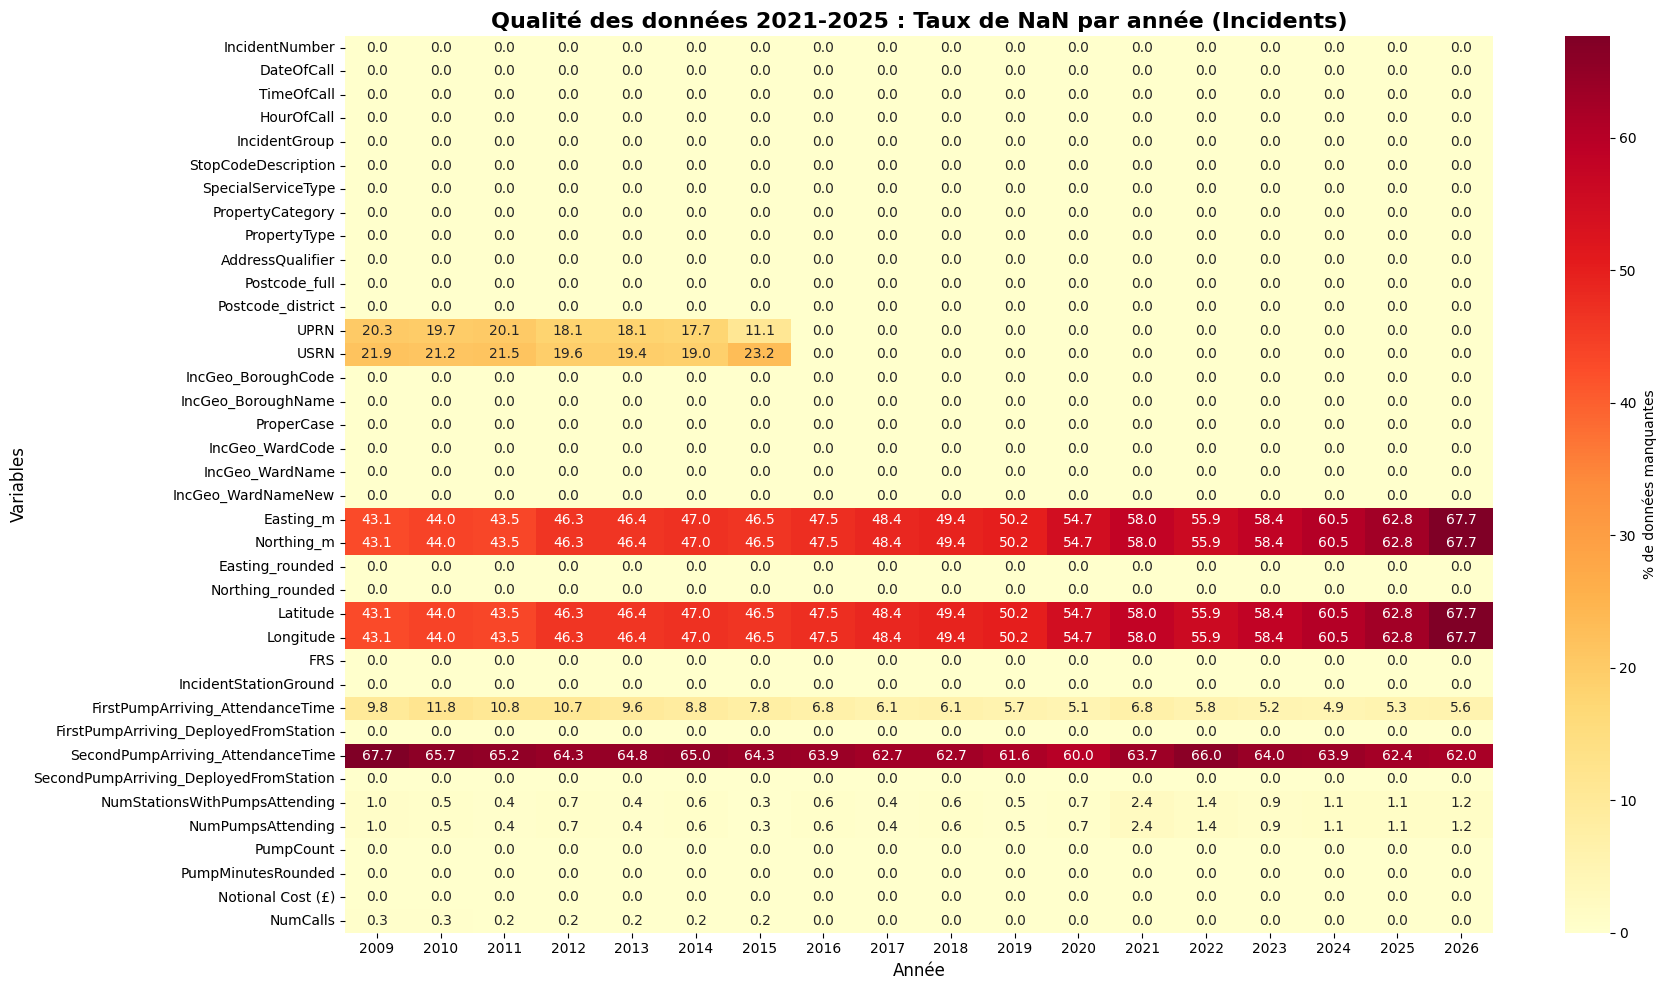

/tmp/ipykernel_17525/2240649578.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_matrix = df.groupby('CalYear').apply(lambda x: x.isna().mean() * 100)


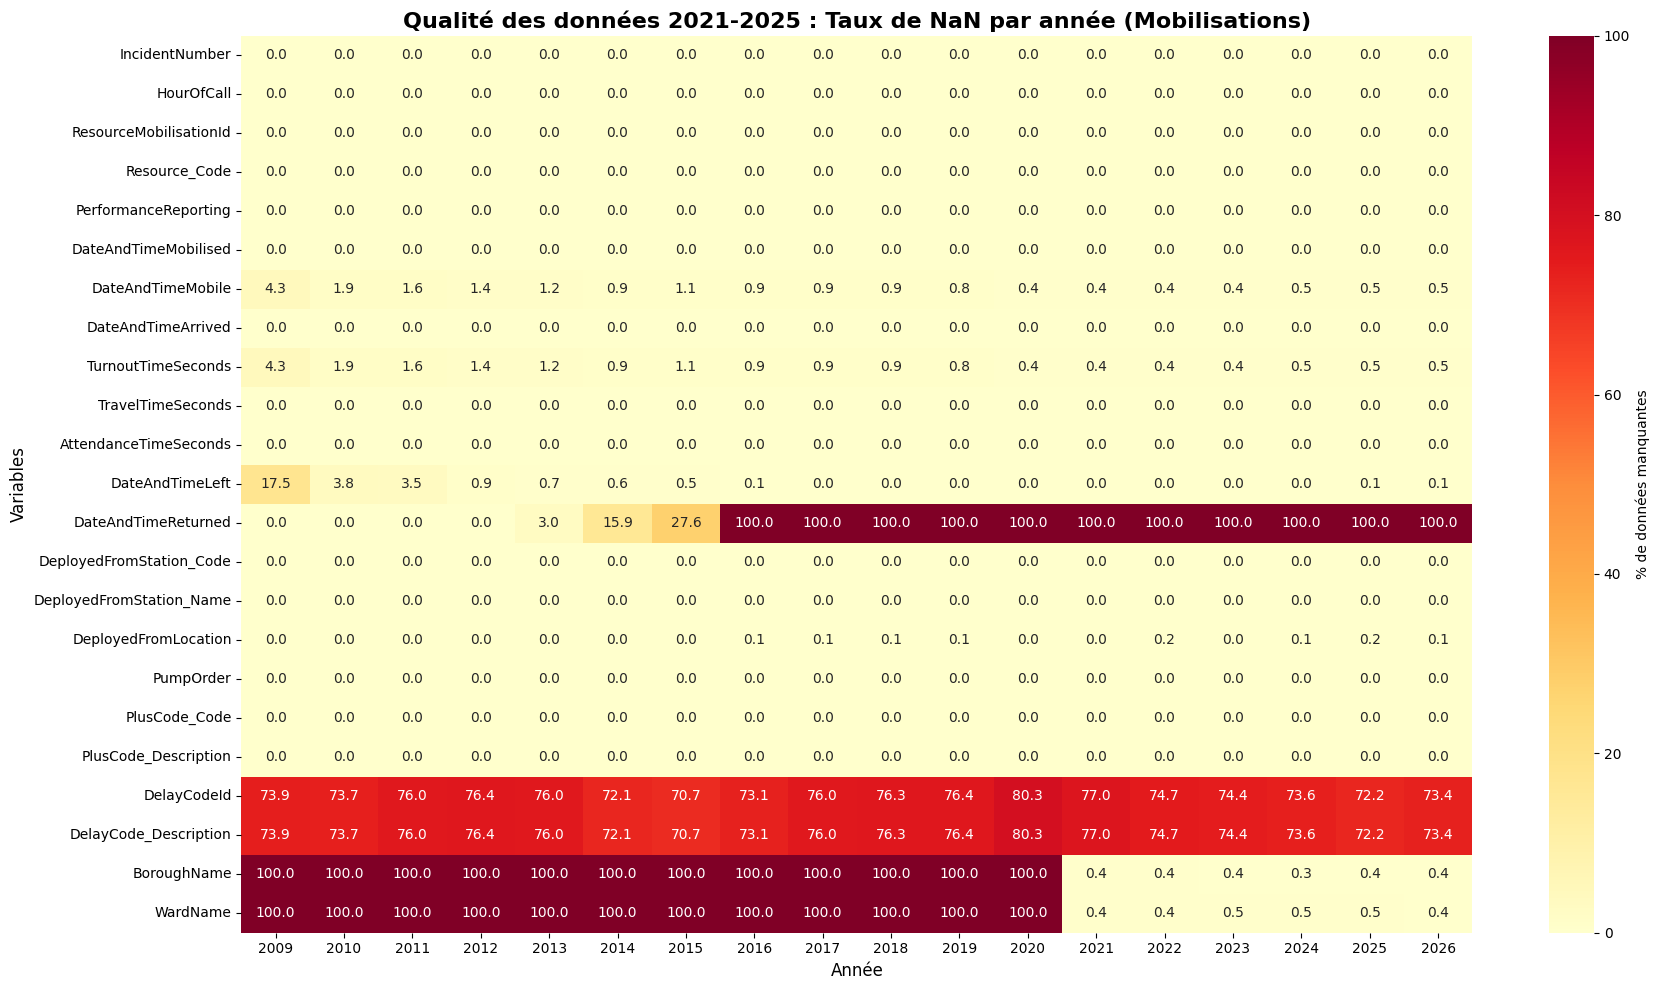

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def generate_nan_heatmap(df, title, filename):
    # Gestion de l'année
    if 'CalYear' not in df.columns:
        # On essaie de trouver une colonne de date disponible
        date_col = 'DateOfCall' if 'DateOfCall' in df.columns else 'IncidentDate'
        if date_col in df.columns:
            df['CalYear'] = pd.to_datetime(df[date_col]).dt.year

    # Calcul du taux de NaN par année (%)
    nan_matrix = df.groupby('CalYear').apply(lambda x: x.isna().mean() * 100)

    # Années en X et variables en Y
    nan_matrix = nan_matrix.T.drop(index='CalYear', errors='ignore')

    # Grpahique
    plt.figure(figsize=(18, 10))
    sns.heatmap(nan_matrix,
                annot=True,
                fmt=".1f",
                cmap="YlOrRd", # Rouge pour les NaN
                cbar_kws={'label': '% de données manquantes'})
    plt.title(f"Qualité des données 2021-2025 : {title}", fontsize=16, fontweight='bold')
    plt.xlabel("Année", fontsize=12)
    plt.ylabel("Variables", fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Graphique 1 : Incidents
generate_nan_heatmap(incident_complet, "Taux de NaN par année (Incidents)", "Heatmap_NaN_Incidents.png")

# Graphique 2 : Mobilisations
generate_nan_heatmap(mobilisation_complet, "Taux de NaN par année (Mobilisations)", "Heatmap_NaN_Mobilisations.png")